/Users/bindhu/Desktop/DL_AI_Intership/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


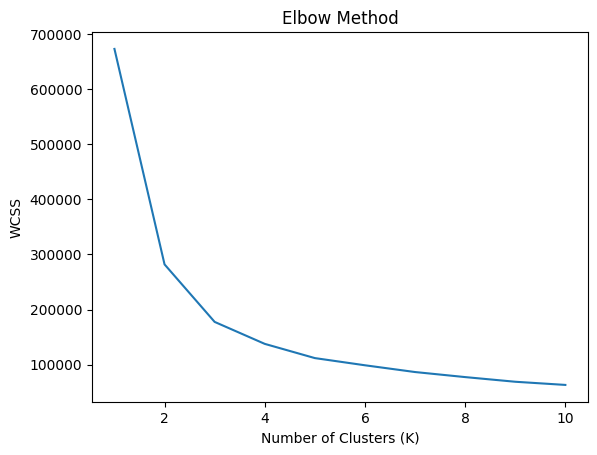

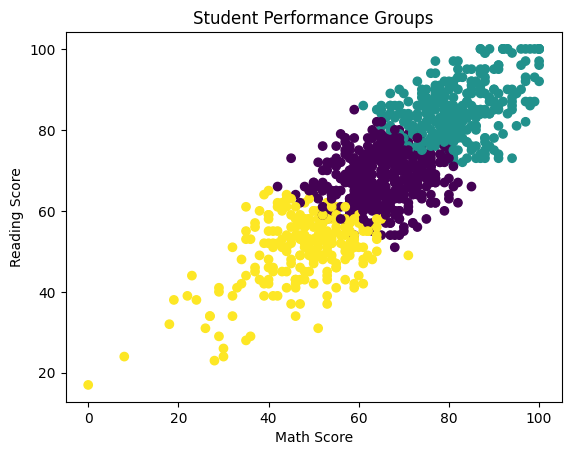

Centroids:
 [[65.19772727 68.32727273 67.69545455]
 [81.66134185 84.98083067 84.02555911]
 [47.94331984 50.63157895 48.4534413 ]]


In [ ]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Download dataset
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

# Load dataset
df = pd.read_csv(path + "/StudentsPerformance.csv")

# Select numerical features
X = df[["math score", "reading score", "writing score"]]

# ---------------------------------
# Elbow Method
# ---------------------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

# ---------------------------------
# Apply K-Means (try K=3)
# ---------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# ---------------------------------
# Visualize Clusters (2D projection)
# ---------------------------------
plt.figure()
plt.scatter(X["math score"], X["reading score"], c=y_kmeans)
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Student Performance Groups")
plt.show()

# ---------------------------------
# Centroids (average scores of each group)
# ---------------------------------
centroids = kmeans.cluster_centers_
print("Centroids:\n", centroids)